In [15]:
import cv2
import numpy as np

def sg2d_jacobian_projection_cv2(Z, window_size=11):
    assert window_size % 2 == 1, "La ventana debe ser impar"
    hw = window_size // 2

    # Coordenadas centradas
    y_idx, x_idx = np.mgrid[-hw:hw+1, -hw:hw+1]

    # Base de regresores (shape: w x w x 6)
    regressors = np.stack([
        x_idx**2,
        y_idx**2,
        x_idx * y_idx,
        x_idx,
        y_idx,
        np.ones_like(x_idx)
    ], axis=-1)  # (w, w, 6)

    A = regressors.reshape(-1, 6)       # (window^2, 6)
    AtA_inv = np.linalg.inv(A.T @ A)
    pseudo = AtA_inv @ A.T              # (6, window^2)

    # Kernels para cada coeficiente: (6, w, w)
    kernels = pseudo.reshape(6, window_size, window_size)

    # Aplicar convoluciones usando OpenCV
    coeffs = np.stack([cv2.filter2D(Z, -1, k, borderType=cv2.BORDER_REFLECT) for k in kernels], axis=-1)
    
    return coeffs  # (N, M, 6)


import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.ndimage import map_coordinates

def plot_fitted_paraboloid_with_principal_directions(Z, coeffs, center, window_size=21,
                                     zlim=5, samples=200):
    """
    - Panel 1: superficie 3D original + ajuste + ejes.
    - Panel 2: imshow de Z_local con semiejes superpuestos.
    - Panel 3: perfil limpio eje 1.
    - Panel 4: perfil limpio eje 2.
    """
    hw = window_size // 2
    i, j = center
    N, M = Z.shape
    if i<hw or i>=N-hw or j<hw or j>=M-hw:
        raise ValueError(f"Centro {center} fuera de rango para ventana {window_size}")

    # Ventana local
    Z_local = Z[i-hw:i+hw+1, j-hw:j+hw+1]
    a, b, c, d, e, f0 = coeffs[i, j, :]

    # Hessiano cuadrático
    Hmat = np.array([[a, c/2],[c/2, b]])
    eigvals, eigvecs = np.linalg.eigh(Hmat)
    # ordenar autovectores
    if eigvals[1]>=eigvals[0]:
        v1, v2 = eigvecs[:,1], eigvecs[:,0]
    else:
        v1, v2 = eigvecs[:,0], eigvecs[:,1]
    # base directa
    if np.cross(v1, v2) < 0:
        v2 = -v2

    # coordenadas locales centradas
    x_loc = np.linspace(-hw, hw, window_size)
    y_loc = np.linspace(-hw, hw, window_size)
    Xg, Yg = np.meshgrid(x_loc, y_loc)

    # ajuste paraboloide
    Z_fit = (a*Xg**2 + b*Yg**2 + c*Xg*Yg +
             d*Xg + e*Yg + f0)

    # figura con 4 subplots
    fig = plt.figure(figsize=(20, 5))

    # 1) Superficie 3D
    ax1 = fig.add_subplot(1, 4, 1, projection='3d')
    ax1.plot_surface(Xg, Yg, Z_local, cmap='viridis',
                     alpha=0.8, edgecolor='k', linewidth=0.3)
    ax1.plot_surface(Xg, Yg, Z_fit, cmap='autumn',
                     alpha=0.6, edgecolor='none')
    ax1.set_zlim(-zlim, zlim)
    ax1.set_title(f"3D Centro: {center}")
    ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("z")

    # 2) imshow + semiejes
    ax2 = fig.add_subplot(1, 4, 2)
    im = ax2.imshow(Z_local, origin='lower',
                    extent=[-hw, hw, -hw, hw], cmap='viridis')
    ax2.set_title("Z_local con semiejes")
    ax2.set_xlabel("x"); ax2.set_ylabel("y")
    fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
    # líneas de semiejes
    scale = hw * 0.8
    for v, color in zip((v1, v2), ('r','b')):
        ax2.plot([0, v[0]*scale], [0, v[1]*scale], color=color, lw=2)
        ax2.plot([0, -v[0]*scale], [0, -v[1]*scale],
                 color=color, lw=1, alpha=1)

    # función de muestreo limpio
    def sample_along(v):
        t = np.linspace(-hw, hw, samples)
        coords = np.vstack([hw + v[1]*t, hw + v[0]*t])  # (fila, col)
        Zorig = map_coordinates(Z_local, coords, order=1, mode='reflect')
        x = v[0]*t; y = v[1]*t
        Zmod = a*x**2 + b*y**2 + c*x*y + d*x + e*y + f0
        return t, Zorig, Zmod

    # 3) perfiles eje 1 (5 consecutivos)
    ax3 = fig.add_subplot(1, 4, 3)
    offsets = np.linspace(-2, 2, 5)  # 5 perfiles, desplazados a lo largo del eje ortogonal
    for k, off in enumerate(offsets):
        # desplazamiento ortogonal a v1
        ortho = np.array([-v1[1], v1[0]])
        def sample_offset(v, offset):
            t = np.linspace(-hw, hw, samples)
            coords = np.vstack([
                hw + v[1]*t + ortho[1]*offset,
                hw + v[0]*t + ortho[0]*offset
            ])
            Zorig = map_coordinates(Z_local, coords, order=1, mode='reflect')
            x = v[0]*t + ortho[0]*offset
            y = v[1]*t + ortho[1]*offset
            Zmod = a*x**2 + b*y**2 + c*x*y + d*x + e*y + f0
            return t, Zorig, Zmod
        t1, z1o, z1m = sample_offset(v1, off)
        ax3.plot(t1, z1o, label=f'Z orig {k+1}', linewidth=1.5)
        ax3.plot(t1, z1m, '--', label=f'Ajuste {k+1}', alpha=0.7)
    ax3.set_title("Perfiles eje 1 (5)")
    ax3.set_xlabel("t"); ax3.set_ylabel("z")
    ax3.grid(True); ax3.legend(fontsize=8)

    # 4) perfiles eje 2 (5 consecutivos)
    ax4 = fig.add_subplot(1, 4, 4)
    offsets = np.linspace(-2, 2, 5)
    ortho2 = np.array([-v2[1], v2[0]])
    for k, off in enumerate(offsets):
        def sample_offset2(v, offset):
            t = np.linspace(-hw, hw, samples)
            coords = np.vstack([
                hw + v[1]*t + ortho2[1]*offset,
                hw + v[0]*t + ortho2[0]*offset
            ])
            Zorig = map_coordinates(Z_local, coords, order=1, mode='reflect')
            x = v[0]*t + ortho2[0]*offset
            y = v[1]*t + ortho2[1]*offset
            Zmod = a*x**2 + b*y**2 + c*x*y + d*x + e*y + f0
            return t, Zorig, Zmod
        t2, z2o, z2m = sample_offset2(v2, off)
        ax4.plot(t2, z2o, label=f'Z orig {k+1}', linewidth=1.5)
        ax4.plot(t2, z2m, '--', label=f'Ajuste {k+1}', alpha=0.7)
    ax4.set_title("Perfiles eje 2 (5)")
    ax4.set_xlabel("t"); ax4.set_ylabel("z")
    ax4.grid(True); ax4.legend(fontsize=8)

    plt.tight_layout()
    plt.show()




def real_to_pixel(x_real, y_real, W, H):
    j = int(np.round((x_real + 1) * (W - 1) / 2))  # columnas (x)
    i = int(np.round((y_real + 1) * (H - 1) / 2))  # filas (y)
    return (i, j)


In [22]:

def slope_difference_filter(Z, window_size=11):
    """
    Realce de deformaciones locales mediante diferencia de pendientes en vecindarios deslizantes.

    Para cada píxel (i, j) se estiman, por mínimos cuadrados, las pendientes lineales
    en dos vecindarios adyacentes horizontales (izquierdo y derecho) y se obtiene
    la imagen de diferencia:

        I(u, v) = m_l(u, v) - m_r(u, v)

    La pendiente en una ventana de N puntos con coordenadas xi se calcula como:

        m = [Σ xi·yi - (1/N)(Σ xi)(Σ yi)] / [Σ xi² - (1/N)(Σ xi)²]

    Parameters
    ----------
    Z           : np.ndarray (H, W), imagen 2D de entrada.
    window_size : int, número de puntos en cada ventana lateral (default 11).

    Returns
    -------
    diff_x : diferencia de pendientes a lo largo del eje X (horizontal).
    """
    import cv2
    import numpy as np

    w = window_size

    def _slope_kernel(x):
        xc = x - x.mean()
        return xc / np.dot(xc, xc)

    x_left  = np.arange(-w, 0, dtype=float)   # [-w, ..., -1]
    x_right = np.arange(1, w + 1, dtype=float) # [ 1, ...,  w]

    k_left  = _slope_kernel(x_left)
    k_right = _slope_kernel(x_right)

    # Kernels horizontales 1×(2w+1)
    K_left_x  = np.zeros((1, 2 * w + 1))
    K_right_x = np.zeros((1, 2 * w + 1))
    K_left_x[0, :w]      = k_left
    K_right_x[0, w + 1:] = k_right

    m_l_x = cv2.filter2D(Z.astype(np.float64), -1, K_left_x,  borderType=cv2.BORDER_REFLECT)
    m_r_x = cv2.filter2D(Z.astype(np.float64), -1, K_right_x, borderType=cv2.BORDER_REFLECT)
    diff_x = m_l_x - m_r_x

    return diff_x


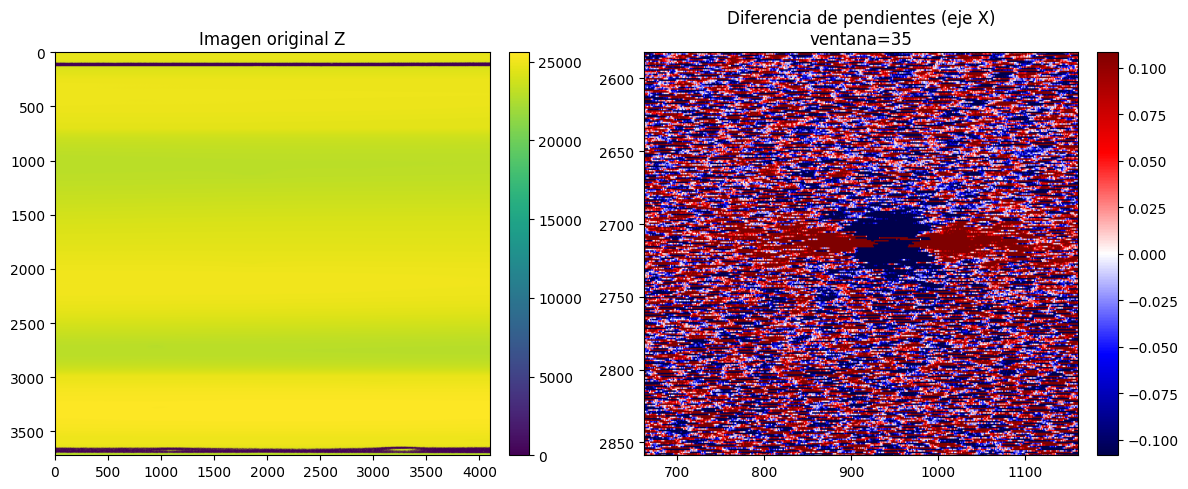

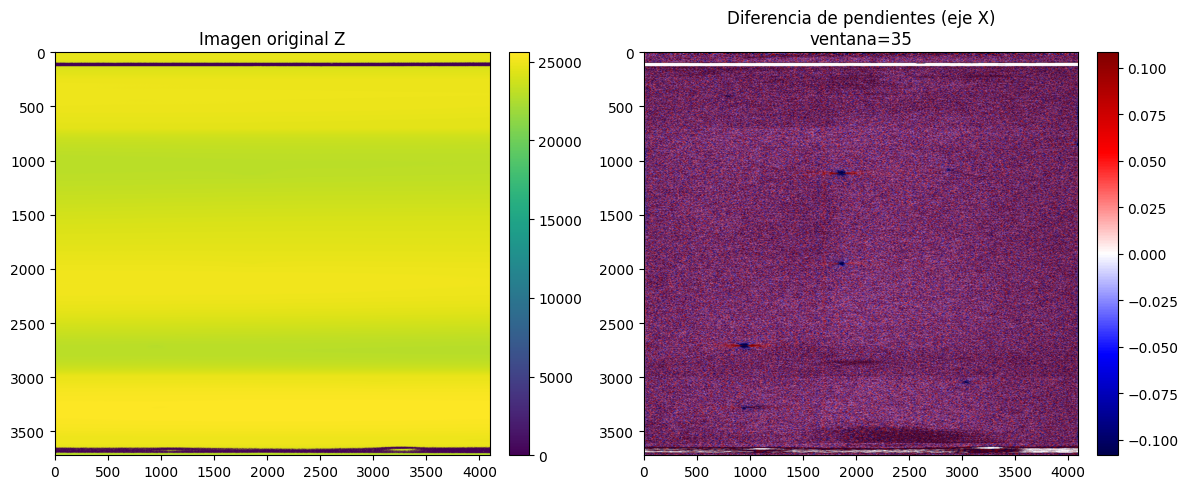

In [32]:
%matplotlib inline

import camera.raw as raw
import matplotlib.pyplot as plt
import numpy as np
import cv2
from scipy.signal import savgol_filter

defects = raw.read_img_raw(f"defectos_reales/picos/step_15_orig.raw")
Z = defects[:, :, 0]  # Extrae el canal único de defects

window_size = 35
diff_x = slope_difference_filter(Z, window_size=window_size)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(Z, cmap='viridis', aspect='auto')
axes[0].set_title("Imagen original Z")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

vmax = np.percentile(np.abs(diff_x), 60)
im1 = axes[1].imshow(diff_x, cmap='seismic', aspect='auto',
                     vmin=-vmax, vmax=vmax)
axes[1].set_title(f"Diferencia de pendientes (eje X)\nventana={window_size}")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


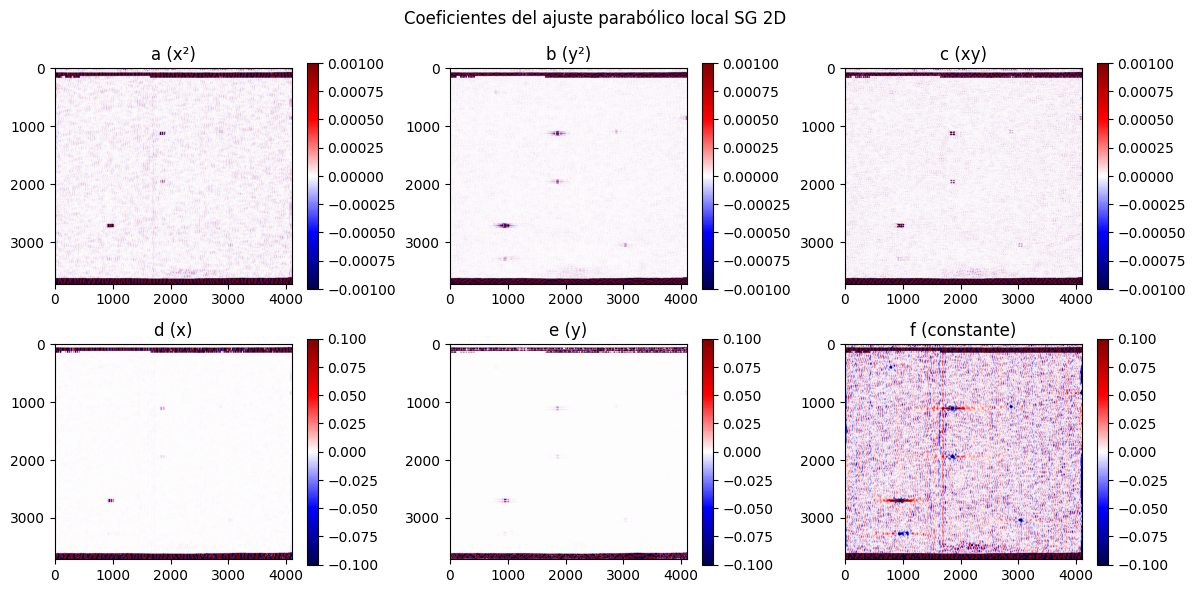

In [43]:

coeffs = sg2d_jacobian_projection_cv2(diff_x, window_size=55)
a, b, c, d, e, f = [coeffs[:, :, i] for i in range(6)]

plt.figure(figsize=(12, 6))
plt.subplot(2, 3, 1); plt.imshow(a, cmap='seismic', vmin=-0.001, vmax=0.001); plt.title("a (x²)"); plt.colorbar()
plt.subplot(2, 3, 2); plt.imshow(b, cmap='seismic', vmin=-0.001, vmax=0.001); plt.title("b (y²)"); plt.colorbar()
plt.subplot(2, 3, 3); plt.imshow(c, cmap='seismic', vmin=-0.001, vmax=0.001); plt.title("c (xy)"); plt.colorbar()
plt.subplot(2, 3, 4); plt.imshow(d, cmap='seismic', vmin=-0.1, vmax=0.1); plt.title("d (x)"); plt.colorbar()
plt.subplot(2, 3, 5); plt.imshow(e, cmap='seismic', vmin=-0.1, vmax=0.1); plt.title("e (y)"); plt.colorbar()
plt.subplot(2, 3, 6); plt.imshow(f, cmap='seismic', vmin=-0.1, vmax=0.1); plt.title("f (constante)"); plt.colorbar()
plt.suptitle("Coeficientes del ajuste parabólico local SG 2D")
plt.tight_layout()
plt.show()

/tmp/ipykernel_290183/662805837.py:66: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  if np.cross(v1, v2) < 0:


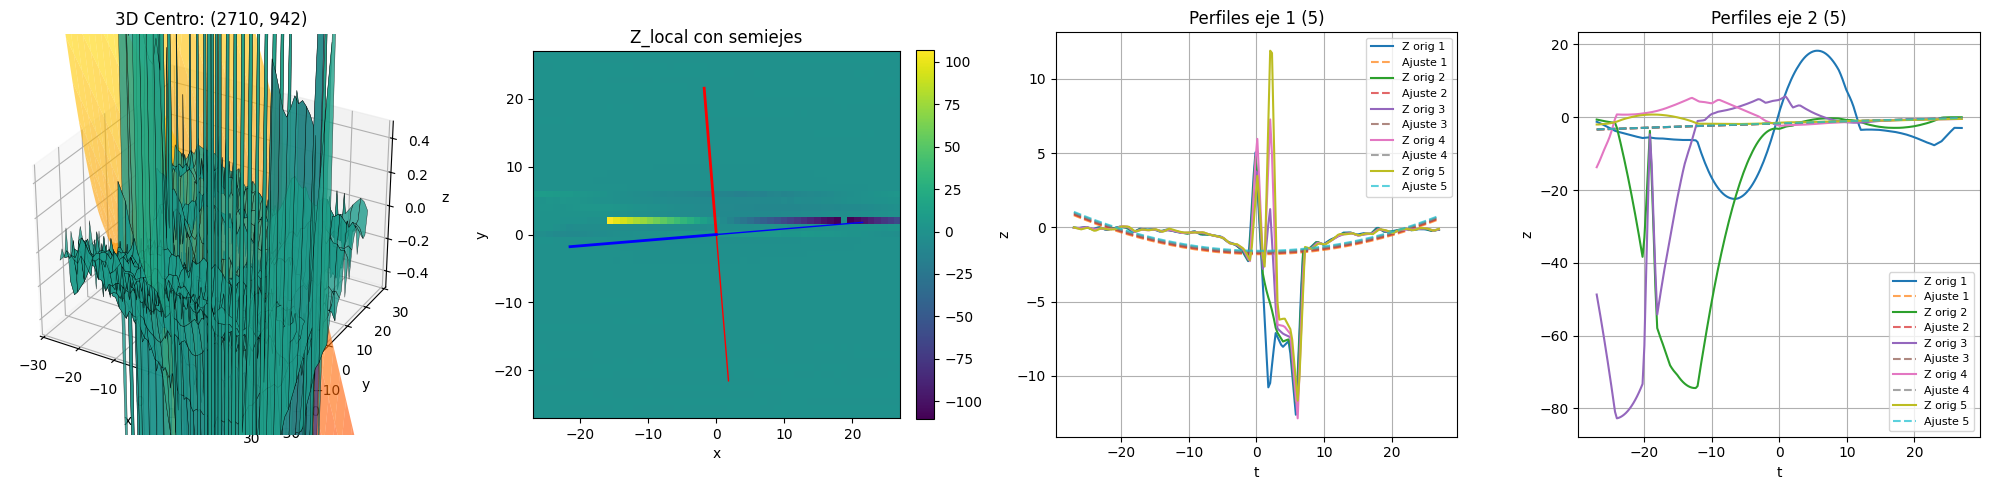

In [44]:
# %matplotlib qt

# Definir el centro en coordenadas de píxel
center = (2710,942)

# Llamar a la función para graficar el paraboloide ajustado en ese centro
plot_fitted_paraboloid_with_principal_directions(diff_x, coeffs, center, window_size=55, zlim=0.5)

In [28]:
import numpy as np
from scipy.ndimage import map_coordinates

def refine_center_line_search(seed, coeffs, 
                              tol=1e-3, max_iter=20,
                              alpha=1.0, beta=0.5, c=1e-4,
                              max_step=50):
    """
    Refinamiento por Newton con back-tracking line-search y control de límites:
    - seed: (i,j) inicial
    - coeffs: array HxWx6 con (a,b,c,d,e,f0)
    - tol: norma del gradiente para convergencia
    - max_iter: iteraciones máximas
    - alpha: paso inicial en búsqueda de línea
    - beta: factor de reducción t en backtrack
    - c: factor Armijo
    - max_step: longitud máxima permitida para delta antes de amortiguación
    Imprime número de iteraciones y controla que el candidato siempre esté dentro de la imagen.
    """
    i_ref, j_ref = seed
    traj = [(i_ref, j_ref)]
    Hh, Wh, _ = coeffs.shape
    
    # separar mapas
    a_map, b_map, c_map, d_map, e_map, _ = [coeffs[..., k] for k in range(6)]
    
    def interp_maps(i, j):
        coords = np.array([[i],[j]])
        a = map_coordinates(a_map, coords, order=1, mode='reflect')[0]
        b = map_coordinates(b_map, coords, order=1, mode='reflect')[0]
        c = map_coordinates(c_map, coords, order=1, mode='reflect')[0]
        d = map_coordinates(d_map, coords, order=1, mode='reflect')[0]
        e = map_coordinates(e_map, coords, order=1, mode='reflect')[0]
        return a, b, c, d, e

    # gradiente inicial
    a, b, c0, d, e = interp_maps(i_ref, j_ref)
    grad_norm = np.hypot(d, e)
    iter_count = 0
    
    for k in range(1, max_iter + 1):
        iter_count = k
        # Hessiano y gradiente
        Hq    = np.array([[2*a,   c0],
                          [  c0, 2*b]])
        grad  = np.array([d, e])
        delta = -np.linalg.solve(Hq, grad)
        
        # limitar longitud del paso antes de line search
        norm_delta = np.linalg.norm(delta)
        if norm_delta > max_step:
            delta *= (max_step / norm_delta)
        
        # backtracking line search con control de límites
        t = alpha
        while t > 1e-4:
            j_cand = j_ref + t * delta[0]
            i_cand = i_ref + t * delta[1]
            # verificar dentro de la imagen
            if not (0 <= i_cand < Hh and 0 <= j_cand < Wh):
                t *= beta
                continue
            # interpolar grad en candidato
            _, _, _, d_new, e_new = interp_maps(i_cand, j_cand)
            if np.hypot(d_new, e_new) <= (1 - c*t) * grad_norm:
                break
            t *= beta
        
        # actualizar
        j_ref = j_ref + t * delta[0]
        i_ref = i_ref + t * delta[1]
        traj.append((i_ref, j_ref))
        
        # recalcular coef y grad
        a, b, c0, d, e = interp_maps(i_ref, j_ref)
        grad_norm = np.hypot(d, e)
        
        if grad_norm < tol:
            break
    
    # print(f"Converged in {iter_count} iterations")
    return (i_ref, j_ref), traj


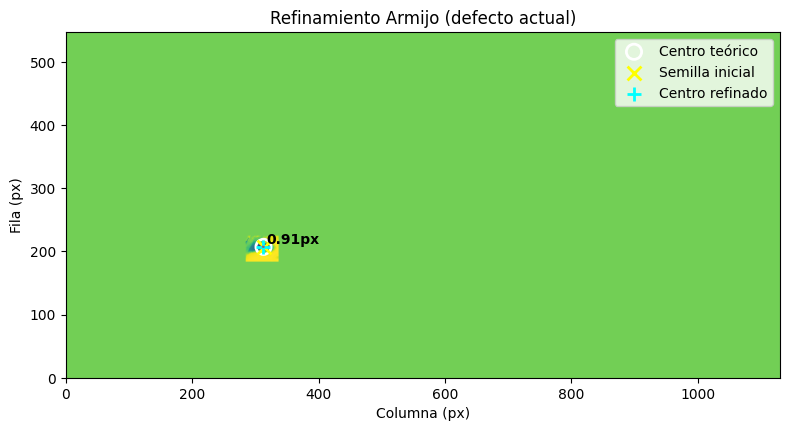

/tmp/ipykernel_83000/662805837.py:66: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  if np.cross(v1, v2) < 0:


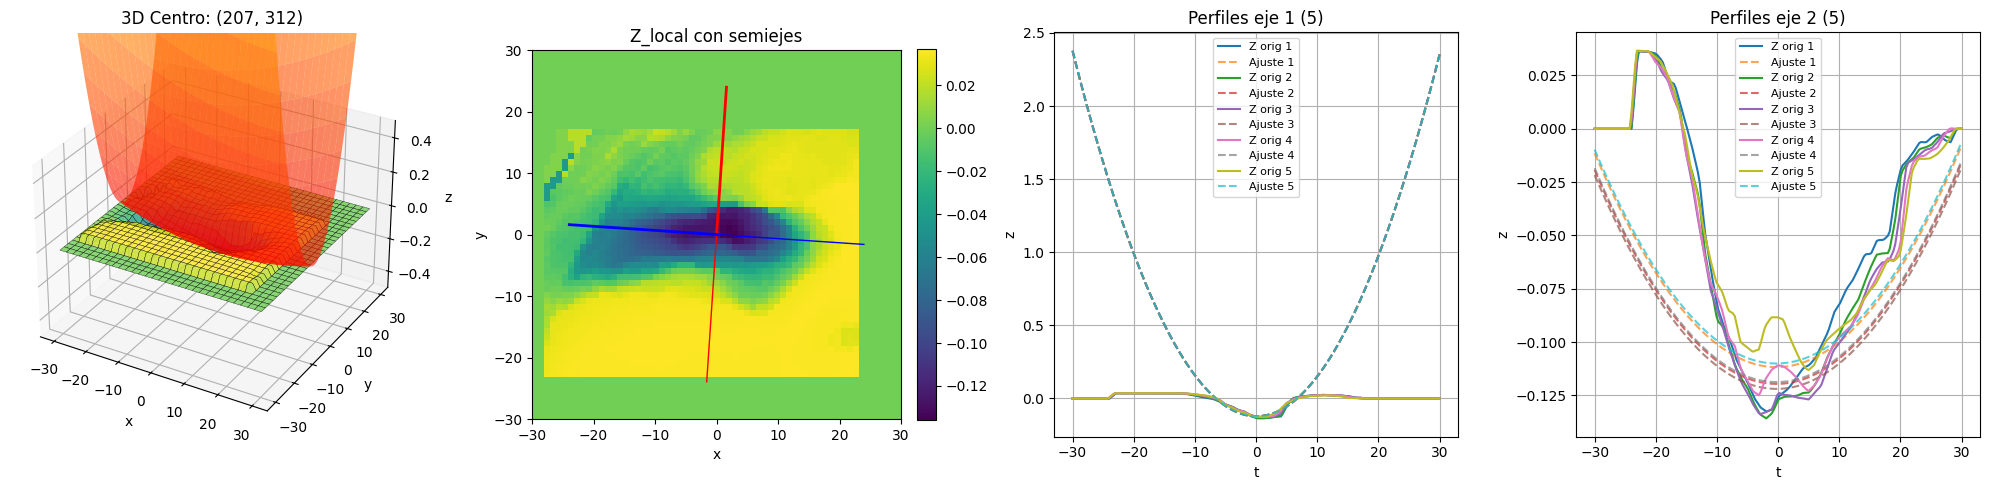

In [29]:
# Parámetros y datos para el defecto actual
H, W = Z.shape

# Usar el centro actual definido en la variable 'center' como semilla
seed_px = center

# Refinamiento iterativo con amortiguación y recogida de trayectoria
tol       = 1e-5
max_iter  = 20000
alpha     = 0.1
refined, traj = refine_center_line_search(seed_px, coeffs, max_iter=max_iter, beta=0.5, tol=tol, alpha=alpha)
distance = np.hypot(refined[0] - center[0], refined[1] - center[1])

# Visualización con anotaciones de distancia
plt.figure(figsize=(8, 8))
plt.imshow(Z, cmap='viridis', origin='lower', extent=[0, W, 0, H])
plt.title("Refinamiento Armijo (defecto actual)")
plt.xlabel("Columna (px)")
plt.ylabel("Fila (px)")

# Centro teórico, semilla, trayectoria y refinado
plt.scatter(center[1], center[0], marker='o', facecolors='none',
            edgecolors='white', s=120, lw=2, label='Centro teórico')
plt.scatter(seed_px[1], seed_px[0], marker='x', color='yellow',
            s=100, lw=2, label='Semilla inicial')

ti, tj = zip(*traj)
plt.plot(tj, ti, '-', color='red', alpha=0.6)

plt.scatter(refined[1], refined[0], marker='+', color='cyan',
            s=100, lw=2, label='Centro refinado')

plt.text(refined[1] + 5, refined[0] + 5, f"{distance:.2f}px",
         color='black', fontsize=10, weight='bold')

plt.legend(loc='upper right')
plt.xlim(0, W)
plt.ylim(0, H)
plt.tight_layout()
plt.show()



# Llamar a la función para graficar el paraboloide ajustado en ese centro
# Convierte las coordenadas refinadas a enteros para usarlas como índices
refined_int = (int(round(refined[0])), int(round(refined[1])))
plot_fitted_paraboloid_with_principal_directions(Z, coeffs, refined_int, window_size=61, zlim=0.5)